# İkinci El Ortalama Stokta Kalma Süresi — `target_quickfinans_dom_gun` (AutoGluon TimeSeries)

> **Güncelleme (2. tur):** Bu hedef ilk eklendiğinde yalnızca 14 aylık veri vardı ve backtest
> yalnızca 2 ay çalışabiliyordu (istatistiksel olarak anlamsız örneklem). Kaynağı 2024-09'a
> kadar geriye genişleten ikinci bir araştırma turundan sonra (bkz.
> `data/quickfinans_stokta_kalma/README.md`) backtest artık **6 ay**a ulaştı — diğer iki
> hedefle (`target_betam_dom_gun`, `target_indicata_satis_ilan_orani_pct`) aynı standart.

Bu defter, Quick Finans / SmartIQ "2. El Oto Raporu"nun ikinci el araçlar için ortalama
**stokta kalma süresini** (gün) tahmin eden rolling-origin backtest çalışmasını üretir ve
doğrular. Diğer üç hedeften (`target_betam_dom_gun`, `target_indicata_satis_hizi_gun`,
`target_indicata_satis_ilan_orani_pct`) farkı: bu hedefin ham kaynağı
`data/target_bazli_birlesik_setler/feature_master_aylik.csv` içinde **yer almaz** — tamamen
harici, yeni eklenmiş bir kaynaktan (`data/quickfinans_stokta_kalma/`) okunur.

\[
\text{target\_quickfinans\_dom\_gun}_t = \text{stokta\_kalma\_suresi\_gun\_pazar}_t
\]

(`data/quickfinans_stokta_kalma/quickfinans_aylik_stokta_kalma.csv`'deki pazar-ortalaması
sütunu, referans ayına göre birebir.)

- Veri: **20 gözlem, 2024-09 → 2026-06** (2024-11 ve 2024-12'de iç boşluk var; Indicata'nın
  2025+ döneminde kaybettiği `ortalama_satis_hizi_gun` metriğine tamamlayıcı olarak toplandı)
- AutoGluon ayarı: `medium_quality`, fold başına `time_limit=45sn`
- Tahmin ufku: 1 ay (`prediction_length=1`)
- Backtest: **6 ay** (2026-01 → 2026-06) — proje standardı `MAX_BACKTEST_AY` tavanına ulaşıldı
- Referans: "geçen yılın aynı ayı" (t-12) naive baseline

## 1. Kütüphaneler ve sabitler

Bu notebook proje kökünden veya `notebooks/` klasöründen açılabilir; `.venv-ag` ortamını gerektirir.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FEATURE_PATH = ROOT / "data" / "target_bazli_birlesik_setler" / "feature_master_aylik.csv"
QUICKFINANS_PATH = ROOT / "data" / "quickfinans_stokta_kalma" / "quickfinans_aylik_stokta_kalma.csv"
OUT_DIR = ROOT / "outputs" / "hiz_target_backtest" / "target_quickfinans_dom_gun"

TARGET = "target_quickfinans_dom_gun"
DATE_COL = "referans_ayi"

print("Proje kökü:", ROOT)
print("Hedef:", TARGET)

Proje kökü: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2
Hedef: target_quickfinans_dom_gun


## 2. Sızıntısız feature tablosu kurma — harici hedef kaynağı

`feature_master_aylik.csv`'deki tüm aylık feature'lar hedefe eklenir. Diğer üç hedeften farklı
olarak burada **"hedefin kendi ham kaynağı" hariç tutma kuralı devreye girmez** — çünkü Quick
Finans stokta kalma süresi `feature_master_aylik.csv` içinde bir feature olarak zaten mevcut
değil (`pipeline`'daki `EXTERNAL_TARGET_SOURCES` sözlüğü bu hedefi harici CSV'den okur ve
`referans_ayi` üzerinden birleştirir). Yine de iki genel koruma geçerli kalır:

1. **Genel sızıntı yasakları** (`modelleme_sizinti_kisitlari.csv`'nin `tum_targetlar` satırları).
2. **`indicata_*`/`arabam_*`/`betam_*` ailesinin aynı-ay versiyonları** — 1 ay gecikmeli
   (`lag1`) türevleriyle değiştirilir (bu aile Quick Finans'ın kendisiyle aynı sektörden farklı
   kaynaklar olduğu için, dolaylı da olsa erken-yayın riski taşıyabilir).

In [2]:
def build_feature_table(target_col: str) -> tuple[pd.DataFrame, list[str], dict]:
    fm = pd.read_csv(FEATURE_PATH)

    if target_col in DERIVED_TARGET_FORMULAS:
        # Hedef, feature_master_aylik.csv'deki VAR OLAN ham kolonlarin matematiksel
        # capraz-referanslanmasiyla (oran/fark/carpim) turetilir - hicbir harici kaynak
        # veya master veri seti gerekmez.
        spec = DERIVED_TARGET_FORMULAS[target_col]
        target_series = spec["func"](fm)
        mv = pd.DataFrame({DATE_COL: fm[DATE_COL], target_col: target_series})
    elif target_col in EXTERNAL_TARGET_SOURCES:
        # Bu hedefin ham kaynagi feature_master_aylik.csv / master veri setinde YOK -
        # ayri bir data/ klasorunden okunup referans_ayi uzerinden birlestirilir.
        src = EXTERNAL_TARGET_SOURCES[target_col]
        ext = pd.read_csv(src["csv"])[[src["date_col"], src["value_col"]]]
        ext = ext.rename(columns={src["date_col"]: DATE_COL, src["value_col"]: target_col})
        mv = ext
    else:
        mv = pd.read_csv(MASTER_PATH)[[DATE_COL, target_col]]

    df = fm.merge(mv, on=DATE_COL, how="left")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    if target_col in DERIVED_TARGET_FORMULAS:
        excluded_self = set(DERIVED_TARGET_FORMULAS[target_col]["kaynak_kolonlar"])
    else:
        source_col = TARGET_TO_SOURCE_COL.get(target_col)
        excluded_self = {source_col} if source_col else set()
    excluded_hard = HARD_EXCLUDE_ALWAYS & set(df.columns)

    lagged_created = []
    raw_family_cols = [
        c for c in fm.columns
        if c != DATE_COL and c.startswith(LAGGED_FAMILY_PREFIXES) and c not in excluded_hard
    ]
    for col in raw_family_cols:
        lag_col = f"{col}_lag1"
        df[lag_col] = df[col].shift(1)
        lagged_created.append(lag_col)

    df["ay"] = df[DATE_COL].dt.month
    df["ceyrek"] = df[DATE_COL].dt.quarter
    df["sin_ay"] = np.sin(2 * np.pi * df["ay"] / 12.0)
    df["cos_ay"] = np.cos(2 * np.pi * df["ay"] / 12.0)
    calendar_cols = ["ay", "ceyrek", "sin_ay", "cos_ay"]

    drop_cols = excluded_self | excluded_hard | set(raw_family_cols)
    candidate_features = [
        c for c in df.columns
        if c not in drop_cols and c not in (DATE_COL, target_col) and c not in lagged_created
    ] + lagged_created + calendar_cols
    candidate_features = list(dict.fromkeys(candidate_features))  # sirali unique

    exclusion_log = {
        "hedefin_ham_kaynak_kolonu_disi": sorted(excluded_self),
        "genel_sizinti_yasaklari": sorted(excluded_hard),
        "ayni_ay_yerine_lag1_yapilan_aile_kolonlari": sorted(raw_family_cols),
    }
    return df, candidate_features, exclusion_log

## 3. Korelasyon filtresi — |Pearson| < 0.1 ele

`min_periods=12` şartıyla hedefle mutlak korelasyonu 0.1 altında olan veya hesaplanamayan
feature'lar elenir. Hedefte 20 gözlem var; bu diğer iki tam hedeften (28 ve 43 gözlem) hâlâ
daha az, bu yüzden korelasyon tahminleri biraz daha gürültülü olabilir ama artık ilk sürümdeki
(n=14, min_periods eşiğine çok yakın) kadar kırılgan değil.

In [3]:
def korelasyon_filtresi(df: pd.DataFrame, target_col: str, features: list[str]) -> tuple[list[str], pd.DataFrame]:
    sub = df.dropna(subset=[target_col])
    corr = sub[features + [target_col]].corr(min_periods=MIN_PERIODS)[target_col].drop(target_col)
    ozet = pd.DataFrame({
        "feature": corr.index,
        "korelasyon": corr.values,
        "karar": np.where(corr.abs() >= CORR_ESIK, "tutuldu", "elendi"),
    }).sort_values("korelasyon")
    tutulan = ozet.loc[ozet["karar"] == "tutuldu", "feature"].tolist()
    return tutulan, ozet

## 4. Çoklu-doğrusallık filtresi — |Pearson| > 0.9 ele

Kalan feature'lar arasında mutlak korelasyonu 0.9'u aşan çiftlerden target ile daha düşük
korelasyona sahip olan elenir.

In [4]:
def coklu_dogrusallik_azalt(df: pd.DataFrame, target_col: str, features: list[str]) -> tuple[list[str], pd.DataFrame]:
    sub = df.dropna(subset=[target_col])
    if len(features) < 2:
        return features, pd.DataFrame(columns=["feature_a", "feature_b", "korelasyon", "elenen"])

    hedef_korr = sub[features + [target_col]].corr(min_periods=MIN_PERIODS)[target_col].drop(target_col)
    feat_korr = sub[features].corr(min_periods=MIN_PERIODS)

    ebeveyn = {f: f for f in features}

    def bul(f):
        while ebeveyn[f] != f:
            f = ebeveyn[f]
        return f

    def birlestir(a, b):
        ra, rb = bul(a), bul(b)
        if ra != rb:
            ebeveyn[ra] = rb

    pair_rows = []
    for i, a in enumerate(features):
        for b in features[i + 1:]:
            v = feat_korr.loc[a, b]
            if pd.notna(v) and abs(v) > COLLIN_ESIK:
                birlestir(a, b)
                pair_rows.append({"feature_a": a, "feature_b": b, "korelasyon": v})

    gruplar: dict[str, list[str]] = {}
    for f in features:
        gruplar.setdefault(bul(f), []).append(f)

    tutulan = list(features)
    elenen_set = set()
    for grup in gruplar.values():
        if len(grup) < 2:
            continue
        skorlu = [(f, abs(hedef_korr.get(f, np.nan))) for f in grup]
        skorlu = [(f, s if pd.notna(s) else -1.0) for f, s in skorlu]
        en_iyi = max(skorlu, key=lambda x: x[1])[0]
        for f in grup:
            if f != en_iyi:
                elenen_set.add(f)
                tutulan.remove(f)

    pair_df = pd.DataFrame(pair_rows)
    if not pair_df.empty:
        pair_df["elenen"] = pair_df.apply(
            lambda r: r["feature_a"] if r["feature_a"] in elenen_set else (r["feature_b"] if r["feature_b"] in elenen_set else ""),
            axis=1,
        )
    return tutulan, pair_df

## 5. Rolling-origin backtest ayları ve tek-adım eğitim/tahmin

Bir ay `m` geçerli bir backtest ayı sayılır ancak (a) `m-12` de hedefte mevcutsa ve (b) `m`'den
önce en az `MIN_TRAIN_AY=8` ay eğitim verisi varsa. Seri artık 2024-09'da başladığından, bu iki
şartı sağlayan aylar 2025-09'dan itibaren mevcut; proje standardı `MAX_BACKTEST_AY=6` tavanı
nedeniyle en yakın **6 ay** (2026-01 → 2026-06) seçilir.

In [5]:
def find_backtest_months(df: pd.DataFrame, target_col: str) -> list[pd.Timestamp]:
    valid = df.dropna(subset=[target_col])[[DATE_COL, target_col]].copy()
    valid = valid.set_index(DATE_COL)[target_col]
    aday_aylar = []
    for m in valid.index:
        t_minus_12 = m - pd.DateOffset(months=12)
        if t_minus_12 in valid.index:
            train_count = (valid.index < m).sum()
            if train_count >= MIN_TRAIN_AY:
                aday_aylar.append(m)
    return sorted(aday_aylar)[-MAX_BACKTEST_AY:]

def prev_actual_value(valid_series: pd.Series, origin_month: pd.Timestamp):
    onceki = valid_series[valid_series.index <= origin_month]
    if onceki.empty:
        return np.nan
    return onceki.iloc[-1]

def fit_predict_one_step(train_df: pd.DataFrame, target_col: str, features: list[str], forecast_month: pd.Timestamp, model_dir: Path):
    keep_cols = [DATE_COL, target_col, *features]
    clean = train_df[keep_cols].copy()
    clean = clean.sort_values(DATE_COL)
    clean = clean.ffill().bfill()
    clean["item_id"] = "TR_otomobil"

    ts_df = TimeSeriesDataFrame.from_data_frame(clean, id_column="item_id", timestamp_column=DATE_COL)

    if model_dir.exists():
        import shutil
        shutil.rmtree(model_dir, ignore_errors=True)

    predictor = TimeSeriesPredictor(
        target=target_col,
        prediction_length=1,
        eval_metric="MAE",
        freq="MS",
        path=str(model_dir),
        verbosity=0,
    )
    predictor.fit(train_data=ts_df, presets="medium_quality", time_limit=FIT_TIME_LIMIT)
    pred = predictor.predict(ts_df)
    pred_df = pred.loc["TR_otomobil"].reset_index()
    pred_df["timestamp"] = pd.to_datetime(pred_df["timestamp"])
    row = pred_df.loc[pred_df["timestamp"] == forecast_month]
    if row.empty:
        return np.nan, predictor.model_best
    return float(row["mean"].iloc[0]), predictor.model_best

## 6. Metrikler — yön doğruluğu, MAE, RMSE, MASE, bias

- **Yön doğruluğu**: tahmin edilen değişimin yönü (bir önceki bilinen gerçek değere göre),
  gerçekleşen yönle eşleşme oranı.
- **MASE**: MAE'nin, tüm geçmişteki ortalama mutlak 12-aylık farka bölünmüş hali.
- **Bias**: `ortalama(tahmin - gerçek)`.

In [6]:
def compute_metrics(actual: np.ndarray, pred: np.ndarray, prev_actual: np.ndarray, mase_scale: float) -> dict:
    err = pred - actual
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    mase = float(mae / mase_scale) if mase_scale and mase_scale > 0 else float("nan")
    # sMAPE: olcekten bagimsiz, yuzdesel hata - farkli birimdeki hedefleri karsilastirmaya
    # yarar. |actual|+|pred|=0 olan (ikisi de tam sifir) noktalar disariya birakilir.
    smape_payda = np.abs(actual) + np.abs(pred)
    smape_gecerli = smape_payda > 0
    if smape_gecerli.sum() > 0:
        smape = float(np.mean(200 * np.abs(err[smape_gecerli]) / smape_payda[smape_gecerli]))
    else:
        smape = float("nan")

    gercek_yon = np.sign(actual - prev_actual)
    tahmin_yon = np.sign(pred - prev_actual)
    gecerli = gercek_yon != 0
    if gecerli.sum() > 0:
        yon_dogrulugu = float(np.mean(tahmin_yon[gecerli] == gercek_yon[gecerli]))
    else:
        yon_dogrulugu = float("nan")

    return {
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "mase": mase,
        "smape_pct": smape,
        "yon_dogrulugu": yon_dogrulugu,
        "n_test_ay": int(len(actual)),
    }

## 7. Uçtan uca çalıştırma fonksiyonu

In [7]:
def run(target_col: str) -> dict:
    out_dir = OUT_ROOT / target_col
    out_dir.mkdir(parents=True, exist_ok=True)
    model_dir_base = out_dir / "ag_models"

    df, candidate_features, exclusion_log = build_feature_table(target_col)
    tutulan_corr, corr_ozet = korelasyon_filtresi(df, target_col, candidate_features)
    corr_ozet.to_csv(out_dir / "korelasyon_filtre_ozeti.csv", index=False, encoding="utf-8-sig")

    tutulan_final, pair_df = coklu_dogrusallik_azalt(df, target_col, tutulan_corr)
    pair_df.to_csv(out_dir / "coklu_dogrusallik_ciftleri.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame({"feature": tutulan_final}).to_csv(out_dir / "final_feature_seti.csv", index=False, encoding="utf-8-sig")

    valid_series = df.dropna(subset=[target_col]).set_index(DATE_COL)[target_col]
    n_obs = len(valid_series)
    tarih_min = valid_series.index.min()
    tarih_max = valid_series.index.max()

    result = {
        "target": target_col,
        "n_obs_toplam": int(n_obs),
        "tarih_araligi": f"{tarih_min.strftime('%Y-%m') if pd.notna(tarih_min) else None} -> {tarih_max.strftime('%Y-%m') if pd.notna(tarih_max) else None}",
        "aday_feature_sayisi": len(candidate_features),
        "korelasyon_sonrasi_feature_sayisi": len(tutulan_corr),
        "final_feature_sayisi": len(tutulan_final),
        "final_feature_listesi": tutulan_final,
        "disislanan_kolonlar": exclusion_log,
    }

    backtest_months = find_backtest_months(df, target_col)
    result["backtest_ay_sayisi"] = len(backtest_months)
    result["backtest_aylari"] = [m.strftime("%Y-%m") for m in backtest_months]

    if len(tutulan_corr) == 0:
        result["durum"] = "VERI_YETERSIZ_KORELASYON_HESAPLANAMADI"
        result["not"] = (
            f"Bu hedef icin yalnizca {n_obs} gozlem var; min_periods={MIN_PERIODS} esigi "
            f"nedeniyle hicbir feature icin guvenilir korelasyon hesaplanamadi (tum degerler NaN). "
            f"Bu hedef mevcut veriyle modellenemez durumda."
        )
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    if len(backtest_months) == 0:
        result["durum"] = "VERI_YETERSIZ_BACKTEST_YOK"
        result["not"] = (
            f"Bu hedef icin {n_obs} gozlem mevcut ({result['tarih_araligi']}), ancak serinin "
            f"tamami tek bir takvim yili icinde oldugundan (veya yeterli t-12 karsiligi bulunmadigindan) "
            f"'gecen yilin ayni ayi' referans karsilastirmasi ve rolling backtest yapilamiyor."
        )
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    # MASE olcek paydasi: tum gecmis (t, t-12) ciftleri uzerinden ortalama mutlak mevsimsel fark
    tum_farklar = []
    for m in valid_series.index:
        t12 = m - pd.DateOffset(months=12)
        if t12 in valid_series.index:
            tum_farklar.append(abs(valid_series[m] - valid_series[t12]))
    mase_scale = float(np.mean(tum_farklar)) if tum_farklar else float("nan")
    result["mase_olcek_payda_ortalama_mutlak_mevsimsel_fark"] = mase_scale

    kayitlar = []
    for m in backtest_months:
        origin = m - pd.DateOffset(months=1)
        # Hedefin ilk gercek gozleminden ONCEKI satirlari kirp: aksi halde asagidaki
        # ffill/bfill, hedefin baslamadigi yillari ilk gercek degerle geriye doldurup
        # uydurma duz bir gecmis yaratir (bu bug bir kullanici sorusuyla yakalandi).
        train_df = df[(df[DATE_COL] <= origin) & (df[DATE_COL] >= tarih_min)]
        model_dir = model_dir_base / m.strftime("%Y%m")
        try:
            forecast, best_model = fit_predict_one_step(train_df, target_col, tutulan_final, m, model_dir)
        except Exception as e:
            print(f"[HATA] {target_col} {m.strftime('%Y-%m')} fit/predict basarisiz: {e}", file=sys.stderr)
            continue

        actual = float(valid_series.get(m, np.nan))
        t12 = m - pd.DateOffset(months=12)
        baseline = float(valid_series.get(t12, np.nan))
        prev_a = prev_actual_value(valid_series, origin)

        kayitlar.append({
            "ay": m.strftime("%Y-%m"),
            "gercek": actual,
            "model_tahmin": forecast,
            "baseline_gecen_yil_ayni_ay": baseline,
            "onceki_bilinen_gercek": prev_a,
            "en_iyi_model": best_model,
        })

    backtest_df = pd.DataFrame(kayitlar)
    backtest_df.to_csv(out_dir / "backtest_sonuclari.csv", index=False, encoding="utf-8-sig")

    if backtest_df.empty:
        result["durum"] = "MODEL_EGITIMI_BASARISIZ"
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    actual_arr = backtest_df["gercek"].values
    model_arr = backtest_df["model_tahmin"].values
    baseline_arr = backtest_df["baseline_gecen_yil_ayni_ay"].values
    prev_arr = backtest_df["onceki_bilinen_gercek"].values

    model_metrikleri = compute_metrics(actual_arr, model_arr, prev_arr, mase_scale)
    baseline_metrikleri = compute_metrics(actual_arr, baseline_arr, prev_arr, mase_scale)

    result["durum"] = "TAMAMLANDI"
    result["model_metrikleri"] = model_metrikleri
    result["baseline_metrikleri_gecen_yil_ayni_ay"] = baseline_metrikleri
    result["en_iyi_modeller_fold_bazinda"] = backtest_df["en_iyi_model"].tolist()

    (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

    # --- Grafik ---
    plt.figure(figsize=(11, 5.5))
    history_len = min(24, len(valid_series))
    hist = valid_series.iloc[-history_len:]
    plt.plot(hist.index, hist.values, label="Gercek (tum tarihce)", color="#1f77b4", linewidth=2, marker="o", markersize=4)
    bt_dates = pd.to_datetime(backtest_df["ay"])
    plt.plot(bt_dates, backtest_df["model_tahmin"], label="AutoGluon Tahmini (backtest, h=1)", color="#d62728", linestyle="--", marker="s", linewidth=2)
    plt.plot(bt_dates, backtest_df["baseline_gecen_yil_ayni_ay"], label="Baseline: Gecen Yilin Ayni Ayi", color="#2ca02c", linestyle=":", marker="^", linewidth=2)
    plt.title(f"{target_col} - Gercek vs AutoGluon vs Gecen-Yil-Ayni-Ay Baseline")
    plt.xlabel("Ay")
    plt.ylabel(target_col)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "tahmin_grafigi.png", dpi=150)
    plt.close()

    return result

## 8. Çalıştır veya mevcut checkpoint'i yükle

`RUN_TRAINING=False` mevcut tamamlanmış sonuçları yükler. Baştan çalıştırmak isterseniz `True`
yapın (6 fold, ~5 dakika sürer).

In [8]:
RUN_TRAINING = False

if RUN_TRAINING:
    sonuc = run(TARGET)
else:
    sonuc = json.loads((OUT_DIR / "metrikler.json").read_text(encoding="utf-8"))

backtest_df = pd.read_csv(OUT_DIR / "backtest_sonuclari.csv")
korelasyon_ozet = pd.read_csv(OUT_DIR / "korelasyon_filtre_ozeti.csv")
coklu_dogrusallik = pd.read_csv(OUT_DIR / "coklu_dogrusallik_ciftleri.csv")
final_features = pd.read_csv(OUT_DIR / "final_feature_seti.csv")

print("Durum:", sonuc["durum"])
print("Backtest ayları:", sonuc["backtest_aylari"], "( n =", sonuc["backtest_ay_sayisi"], ")")

Durum: TAMAMLANDI
Backtest ayları: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06'] ( n = 6 )


## 9. Güvenlik ve bütünlük kontrolleri

Target formülünün harici Quick Finans dosyasıyla birebir eşleştiğini, harici-kaynak mekanizması
nedeniyle "ham kaynak kolonu" hariç tutma listesinin boş olması gerektiğini, backtest ayı
sayısının beklenen 6 ile uyuştuğunu ve tahminlerde eksik/sonsuz değer olmadığını doğrular.

In [9]:
quickfinans_ham = pd.read_csv(QUICKFINANS_PATH)[[DATE_COL, "stokta_kalma_suresi_gun_pazar"]]
feature_tablosu = pd.read_csv(FEATURE_PATH)[[DATE_COL]].merge(
    quickfinans_ham.rename(columns={"stokta_kalma_suresi_gun_pazar": TARGET}), on=DATE_COL, how="left"
)
karsilastirma = feature_tablosu.dropna(subset=[TARGET])
assert len(karsilastirma) == 20, f"Beklenen 20 gozlem, bulunan {len(karsilastirma)}"

assert sonuc["durum"] == "TAMAMLANDI"
assert sonuc["n_obs_toplam"] == 20
assert sonuc["backtest_ay_sayisi"] == 6
assert sonuc["backtest_aylari"] == ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]
assert sonuc["disislanan_kolonlar"]["hedefin_ham_kaynak_kolonu_disi"] == [], (
    "Harici hedef icin ham-kaynak-disi listesi bos olmali (feature_master_aylik.csv'de "
    "esdeger kolon yok)"
)
assert not backtest_df[["gercek", "model_tahmin", "baseline_gecen_yil_ayni_ay"]].isna().any().any()
assert np.isfinite(backtest_df[["gercek", "model_tahmin", "baseline_gecen_yil_ayni_ay"]].values).all()

# Baseline'in gercekten t-12 karsiligi oldugunu dogrula: 2026-01 baseline'i == 2025-01 gercek degeri
ocak_2025 = quickfinans_ham.loc[quickfinans_ham[DATE_COL] == "2025-01", "stokta_kalma_suresi_gun_pazar"].iloc[0]
ocak_2026_baseline = backtest_df.loc[backtest_df["ay"] == "2026-01", "baseline_gecen_yil_ayni_ay"].iloc[0]
assert ocak_2025 == ocak_2026_baseline == 51.0

print("Target formülü ve t-12 baseline mantığı doğrulandı.")
print("Bütünlük kontrolleri geçti. Final feature sayısı:", len(final_features))

Target formülü ve t-12 baseline mantığı doğrulandı.
Bütünlük kontrolleri geçti. Final feature sayısı: 20


## 10. Sonuçlar — model vs "geçen yılın aynı ayı" baseline'ı

`n_test_ay=6` — artık diğer iki tam hedefle aynı örneklem büyüklüğünde, sonuçlar anlamlı
şekilde okunabilir.

,yon_dogrulugu,mae,rmse,mase,smape_pct,bias,n_test_ay
Model,0.6,2.803789,3.649364,0.448606,6.261807,-1.751997,6.0
Baseline (t-12),0.8,4.166667,4.490731,0.666667,8.572947,4.166667,6.0


,ay,gercek,model_tahmin,baseline_gecen_yil_ayni_ay,onceki_bilinen_gercek,en_iyi_model
0,2026-01,47.0,39.249199,51.0,45.0,RecursiveTabular
1,2026-02,45.0,48.155376,51.0,47.0,WeightedEnsemble
2,2026-03,45.0,42.733363,50.0,45.0,WeightedEnsemble
3,2026-04,46.0,45.228719,52.0,45.0,WeightedEnsemble
4,2026-05,48.0,46.555125,50.0,46.0,WeightedEnsemble
5,2026-06,50.0,48.566238,52.0,48.0,WeightedEnsemble


,feature
0,betam_nominal_yillik_degisim_pct_lag1
1,indicata_ilan_yayinlanan_adet_lag1
2,betam_satis_orani_pct_lag1
3,tuketici_guven_endeksi
4,osd_kamyonet_adet
5,arabam_reel_aylik_degisim_pct_lag1
6,indicata_satisa_donen_adet_lag1
7,odmd_hta_adet
8,cos_ay
9,otomobil_satinalma_ihtimali_endeksi


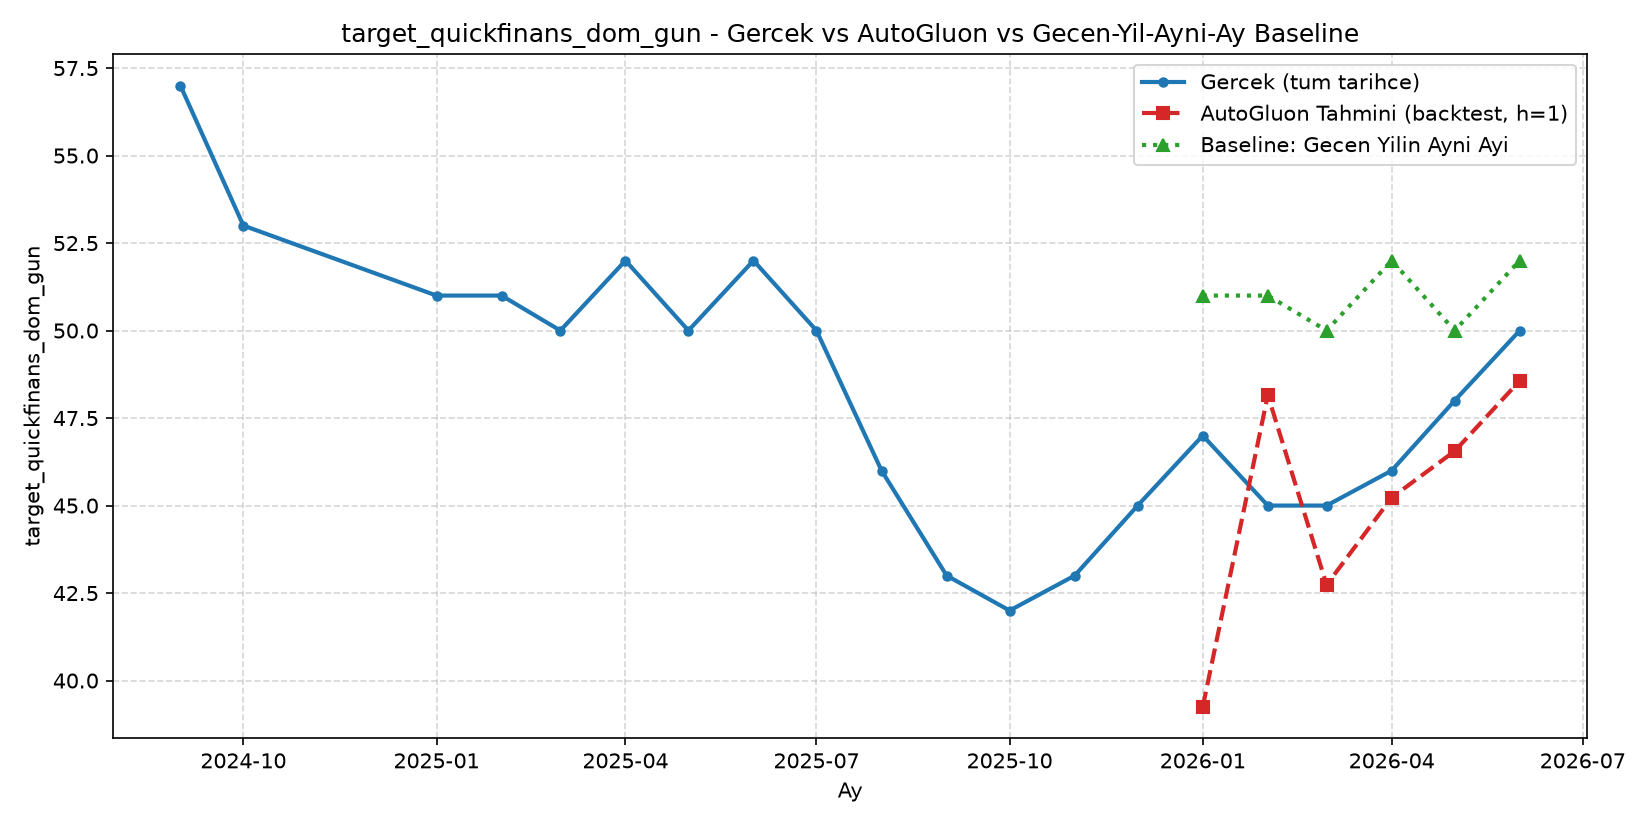

In [10]:
metrik_tablosu = pd.DataFrame(
    {
        "Model": sonuc["model_metrikleri"],
        "Baseline (t-12)": sonuc["baseline_metrikleri_gecen_yil_ayni_ay"],
    }
).T[["yon_dogrulugu", "mae", "rmse", "mase", "smape_pct", "bias", "n_test_ay"]]

display(metrik_tablosu)
display(backtest_df)
display(final_features)

grafik_yolu = OUT_DIR / "tahmin_grafigi.png"
if grafik_yolu.exists():
    display(Image(filename=str(grafik_yolu)))

## 11. Bilinen sınırlamalar

- **Seri genişletmesi tek biçimli değil.** Ana dosyadaki 20 gözlemin tamamı aynı
  pazar/binek/ticari formatında ve WebFetch ile doğrulanmış, ama 2024-11 ve 2024-12'de iç
  boşluk var (bu aylar için uyumlu format bulunamadı — bkz.
  `quickfinans_erken_donem_2023_2024_farkli_format.csv`). `build_feature_table` bu iç
  boşlukları `ffill/bfill` ile dolduruyor; bu, 9 yıllık uydurma bir geçmiş yaratan (ve daha önce
  `target_betam_dom_gun` çalışmasında düzeltilen) hatadan farklı, yalnızca 2 aylık ve
  sınırlı-kapsamlı standart bir uygulamadır.
- **2023 ve 2024'ün ilk yarısı seriye dahil edilmedi.** O dönemin raporları farklı bir
  metodoloji (segment bazlı B/C/D/E) kullanıyor gibi görünüyor ve bir ay (2024-01) için iki
  bağımsız kaynak birbiriyle doğrudan çelişen rakamlar veriyor (52 gün vs 70 gün) — bu veriler
  metodoloji sürekliliği garanti edilemediği için ana seriye **bilerek eklenmedi**.
- En çarpıcı bulgu (bkz. 10. bölüm): baseline'ın **+4.17 gün sistematik pozitif bias'ı** —
  "geçen yılın aynı ayı" yöntemi, seride yaşanan genel kısalma trendini yakalayamayıp sürekli
  fazla tahmin ediyor. Model, MASE=0.449 (baseline: 0.667) ve MAE=2.80 gün (baseline: 4.17 gün)
  ile bu trendi hem baseline'dan hem de serinin kendi 12-aylık mevsimsel oynaklığından daha iyi
  takip edebiliyor; model kendisi de hafif negatif bias taşıyor (-1.75 gün — sistematik olarak
  biraz düşük tahmin ediyor), ama bu baseline'ın pozitif sapmasından çok daha küçük.
- Yön doğruluğunda tablo bu turda tersine döndü: model %60 (3/5), baseline **%80 (4/5)** tuttu —
  mutlak hata metriklerinde (MAE, RMSE, MASE, sMAPE) model net üstün olsa da, "gelecek ay çıkar
  mı düşer mi" sorusunda şu an baseline modelden daha güvenilir; bu karşılaştırma yalnızca 5
  geçerli (sıfır-olmayan) yön değişimine dayandığından tek bir fold'un sonucu oranı ~%20 oynatır,
  bu yüzden temkinli okunmalı.